# Four Runners — Sections 1 and 2

## A storytelling contribution based on 80,000 simulated runners

> **SIMULATED POPULATION** — Every number and comparison in these two sections describes the synthetic Run Club Marathon dataset. The profiles are descriptive labels, not natural categories or advice for runners.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {0: '#5B8FF9', 1: '#61DDAA', 2: '#F6BD16', 3: '#E8684A'}
NAME_MAP = {0: 'Newcomers', 1: 'Regulars', 2: 'Naturals', 3: 'Veterans'}

def find_data_dir():
    for candidate in [Path('../data'), Path('data')]:
        if (candidate / 'clean.csv').exists() and (candidate / 'profiles.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find data/clean.csv and data/profiles.csv')

DATA = find_data_dir()
clean = pd.read_csv(DATA / 'clean.csv')
profiles = pd.read_csv(DATA / 'profiles.csv')
df = clean.merge(profiles, on='runner_id', how='inner', validate='one_to_one')
df['profile_name'] = df['profile'].map(NAME_MAP)

assert len(df) == 80_000
assert df['profile'].nunique() == 4
print(f'{len(df):,} simulated runners | {df["profile"].nunique()} descriptive profiles')


80,000 simulated runners | 4 descriptive profiles


## 1. Meet four runners

At the starting line, **80,000 simulated runners** appear to be preparing for the same race. Their preparation, however, tells four different stories.

The largest region contains the **Newcomers**. They represent **43.9% of this simulated population** and have accumulated about **21 months of running experience**. They run less frequently than the other profiles, and **70% follow the beginner programme**. Their average finishing time is approximately **301 minutes in this simulated dataset**.

The **Regulars** account for **24.8% of the simulated runners**. They run about **5.2 times per week**, but their weekly mileage remains relatively low. Their pattern is therefore one of frequent, comparatively short sessions. They complete the marathon in approximately **292 minutes on average in this simulated population**.

The **Naturals**, representing **16.0% of the simulated population**, stand out for their aerobic indicators rather than their training load. Their average VO₂ max is approximately **65**, while the rest of their training is closer to the middle of the dataset. They finish in approximately **283 minutes on average in the simulation**.

Finally, the **Veterans** make up **15.2% of the simulated runners**. They have approximately **95 months of experience**, cover around **22.5 miles per week** and complete the most speed-work sessions. About **85% follow the advanced programme**. With an average finishing time of approximately **250 minutes in this simulated population**, they are the fastest profile.

These names make the patterns easier to remember, but they should not be mistaken for four natural kinds of runner. K-means divides a continuous population into useful regions; the boundaries are analytical choices, and the profiles still overlap.


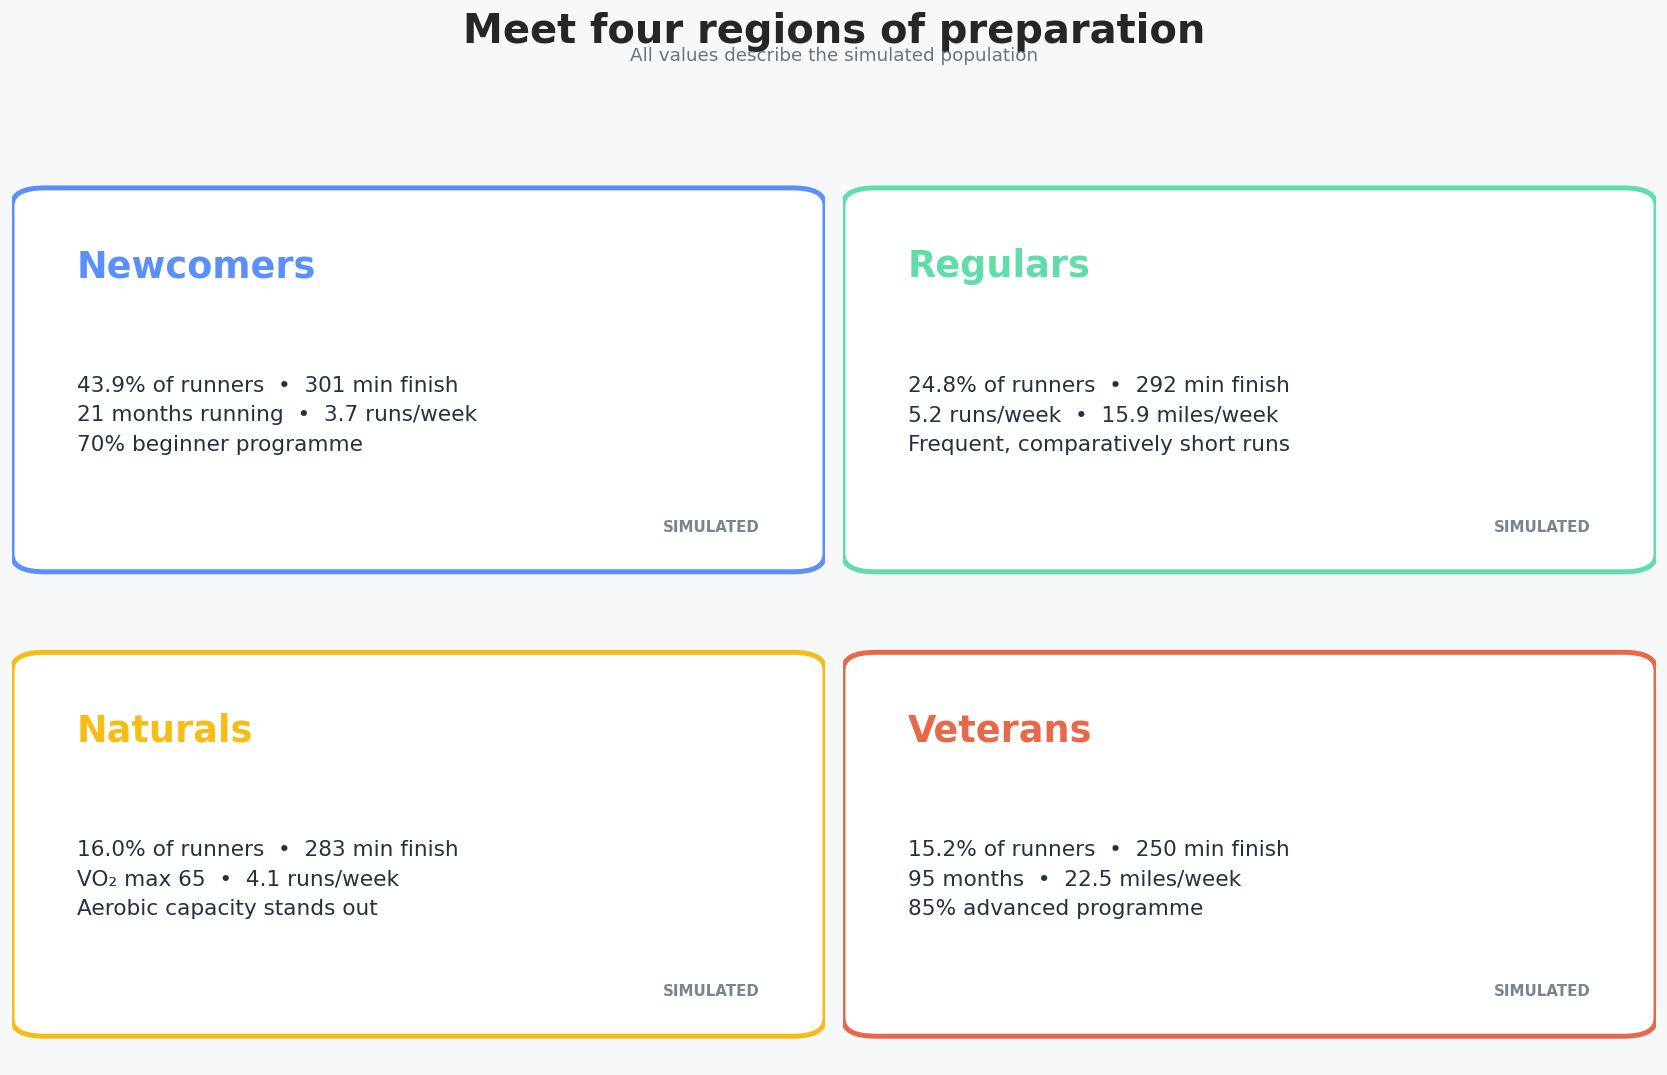

In [2]:
profile_stats = (
    df.groupby(['profile', 'profile_name'], as_index=False)
      .agg(
          runners=('runner_id', 'size'),
          experience_months=('running_experience_months', 'mean'),
          runs_per_week=('runs_per_week', 'mean'),
          weekly_miles=('weekly_mileage_miles', 'mean'),
          vo2_max=('vo2_max', 'mean'),
          speed_sessions=('speed_work_sessions_per_week', 'mean'),
          finish_minutes=('actual_finish_time_minutes', 'mean'),
          dnf_rate=('dnf', 'mean'),
      )
      .sort_values('profile')
)
profile_stats['share'] = profile_stats['runners'] / len(df) * 100
programme = pd.crosstab(df['profile'], df['training_program'], normalize='index') * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#F7F8FA')

descriptions = {
    0: lambda r: f"{r.share:.1f}% of runners  •  {r.finish_minutes:.0f} min finish\n{r.experience_months:.0f} months running  •  {r.runs_per_week:.1f} runs/week\n{programme.loc[0, 'Beginner']:.0f}% beginner programme",
    1: lambda r: f"{r.share:.1f}% of runners  •  {r.finish_minutes:.0f} min finish\n{r.runs_per_week:.1f} runs/week  •  {r.weekly_miles:.1f} miles/week\nFrequent, comparatively short runs",
    2: lambda r: f"{r.share:.1f}% of runners  •  {r.finish_minutes:.0f} min finish\nVO₂ max {r.vo2_max:.0f}  •  {r.runs_per_week:.1f} runs/week\nAerobic capacity stands out",
    3: lambda r: f"{r.share:.1f}% of runners  •  {r.finish_minutes:.0f} min finish\n{r.experience_months:.0f} months  •  {r.weekly_miles:.1f} miles/week\n{programme.loc[3, 'Advanced']:.0f}% advanced programme",
}

for ax, row in zip(axes.flat, profile_stats.itertuples()):
    ax.set_facecolor('#F7F8FA')
    ax.axis('off')
    card = FancyBboxPatch((0.02, 0.08), 0.96, 0.82,
                          boxstyle='round,pad=0.02,rounding_size=0.04',
                          transform=ax.transAxes, facecolor='white',
                          edgecolor=COLORS[row.profile], linewidth=3)
    ax.add_patch(card)
    ax.text(0.08, 0.72, row.profile_name, transform=ax.transAxes,
            fontsize=22, fontweight='bold', color=COLORS[row.profile])
    ax.text(0.08, 0.50, descriptions[row.profile](row), transform=ax.transAxes,
            fontsize=13, va='top', linespacing=1.6, color='#273142')
    ax.text(0.92, 0.15, 'SIMULATED', transform=ax.transAxes, ha='right',
            fontsize=9, fontweight='bold', color='#7A8493')

fig.suptitle('Meet four regions of preparation', fontsize=24, fontweight='bold', y=0.99)
fig.text(0.5, 0.945, 'All values describe the simulated population', ha='center',
         fontsize=11, color='#6B7280')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## 2. Fifty-one minutes apart

The distance between the two ends of the profile continuum is substantial. In this simulated population, Newcomers finish in approximately **300.9 minutes**, compared with **249.6 minutes for Veterans**: a difference of **51.3 minutes**.

This is not merely a restatement of how the profiles were created. Neither finishing time nor drop-out status was included in the clustering. The runners were grouped using pre-race characteristics such as experience, training behaviour and physical condition. Only afterwards were their marathon outcomes compared. Put simply: **we sorted the simulated runners by how they prepared, and the results separated afterwards**.

The same contrast appears in completion. **3.2% of Newcomers did not finish in this simulated population**, compared with **1.5% of Veterans**. The Newcomer DNF rate is therefore slightly more than twice the Veteran rate. This remains a descriptive comparison: it does not establish that membership in a profile causes either outcome.

The profiles also overlap. Some Newcomers finish ahead of some Veterans, and the labels do not determine an individual result. What they reveal is a population-level gradient: as the preparation pattern shifts from limited experience and lower training frequency toward accumulated experience and higher training load, the distribution of outcomes also shifts.

The **51-minute simulated gap** creates the next question. Is experience equally valuable at every stage of a runner’s development, or does its relationship with finishing time change as experience accumulates?


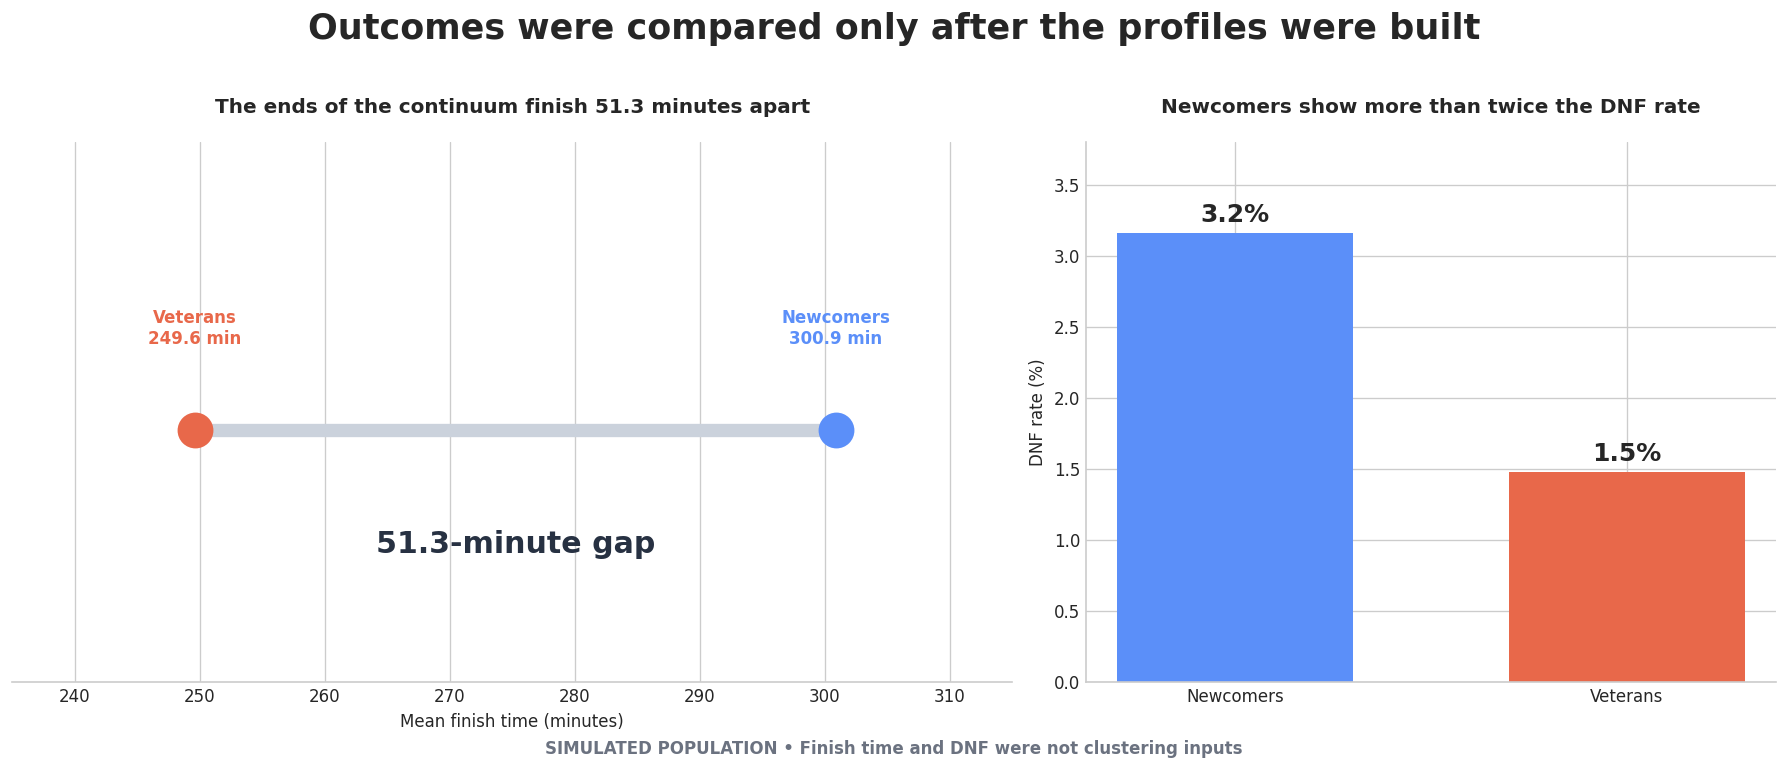

In [3]:
comparison = profile_stats.set_index('profile')
new = comparison.loc[0]
vet = comparison.loc[3]
gap = new['finish_minutes'] - vet['finish_minutes']

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.45, 1]})
fig.patch.set_facecolor('white')

# Finish-time gap
ax = axes[0]
y = 0
ax.plot([vet['finish_minutes'], new['finish_minutes']], [y, y], color='#CBD2DC', lw=8, solid_capstyle='round')
ax.scatter(vet['finish_minutes'], y, s=420, color=COLORS[3], zorder=3, label='Veterans')
ax.scatter(new['finish_minutes'], y, s=420, color=COLORS[0], zorder=3, label='Newcomers')
ax.text(vet['finish_minutes'], y + 0.12, f"Veterans\n{vet['finish_minutes']:.1f} min", ha='center', fontweight='bold', color=COLORS[3])
ax.text(new['finish_minutes'], y + 0.12, f"Newcomers\n{new['finish_minutes']:.1f} min", ha='center', fontweight='bold', color=COLORS[0])
ax.text((vet['finish_minutes'] + new['finish_minutes']) / 2, y - 0.17,
        f"{gap:.1f}-minute gap", ha='center', fontsize=18, fontweight='bold', color='#273142')
ax.set_xlim(235, 315)
ax.set_ylim(-0.35, 0.4)
ax.set_yticks([])
ax.set_xlabel('Mean finish time (minutes)')
ax.set_title('The ends of the continuum finish 51.3 minutes apart', fontweight='bold', pad=18)
for spine in ['left', 'right', 'top']:
    ax.spines[spine].set_visible(False)

# DNF comparison
ax = axes[1]
labels = ['Newcomers', 'Veterans']
rates = [new['dnf_rate'] * 100, vet['dnf_rate'] * 100]
bars = ax.bar(labels, rates, color=[COLORS[0], COLORS[3]], width=0.6)
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in rates], padding=4, fontsize=15, fontweight='bold')
ax.set_ylim(0, 3.8)
ax.set_ylabel('DNF rate (%)')
ax.set_title('Newcomers show more than twice the DNF rate', fontweight='bold', pad=18)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Outcomes were compared only after the profiles were built', fontsize=21, fontweight='bold', y=1.02)
fig.text(0.5, -0.01, 'SIMULATED POPULATION • Finish time and DNF were not clustering inputs',
         ha='center', fontsize=10, fontweight='bold', color='#6B7280')
plt.tight_layout()
plt.show()


### Handoff to Section 3

> The profiles show a **51.3-minute difference in this simulated population**, but averages alone cannot show where experience matters most. The next section follows the experience curve and asks why its steepest part appears near the beginning.
